In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st 
import seaborn as sns
g_s= pd.read_csv(r"C:\Users\Lenovo\Desktop\Python proyectos\titanic proyecto\gender_submission.csv")
train = pd.read_csv(r"C:\Users\Lenovo\Desktop\Python proyectos\titanic proyecto\train.csv")
test = pd.read_csv(r"C:\Users\Lenovo\Desktop\Python proyectos\titanic proyecto\test.csv")
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [15]:
print(train.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [16]:
print(test.head())

   PassengerId  Pclass                                          Name     Sex  \
0          892       3                              Kelly, Mr. James    male   
1          893       3              Wilkes, Mrs. James (Ellen Needs)  female   
2          894       2                     Myles, Mr. Thomas Francis    male   
3          895       3                              Wirz, Mr. Albert    male   
4          896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female   

    Age  SibSp  Parch   Ticket     Fare Cabin Embarked  
0  34.5      0      0   330911   7.8292   NaN        Q  
1  47.0      1      0   363272   7.0000   NaN        S  
2  62.0      0      0   240276   9.6875   NaN        Q  
3  27.0      0      0   315154   8.6625   NaN        S  
4  22.0      1      1  3101298  12.2875   NaN        S  


In [17]:
#Notamos que nos falta la columna Survived (0,1) de "head", nuestro objetivo será predecir sus valores apartir de datos que ya conocemos ("train")

In [18]:
#Indagamos sobre train:

In [19]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [20]:
print(train.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [21]:
#Contamos cuántos datos NA tienen las columnas de "train"

In [22]:
print(train.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [23]:
Q1 = train['Age'].quantile(0.25)
Q3 = train['Age'].quantile(0.75)
IQR = Q3 -Q1
lim_inf = Q1 - 1.5*IQR
lim_sup = Q3 + 1.5*IQR

outliers = train[(train['Age']<lim_inf)|(train['Age']>lim_sup)]
num= len(outliers)
num



11

In [24]:
print(f"Tiene {num} outliers")

Tiene 11 outliers


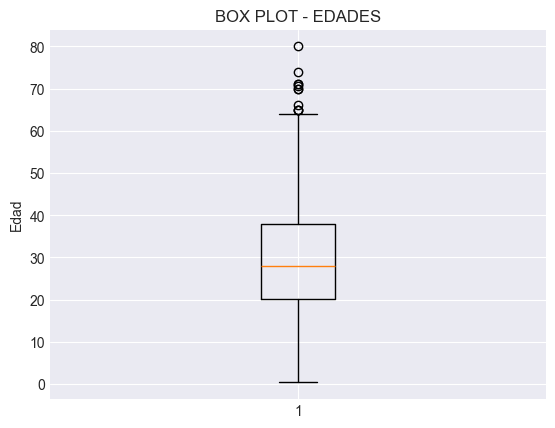

In [25]:
plt.boxplot(train["Age"].dropna())
plt.ylabel("Edad")
plt.title("BOX PLOT - EDADES")
plt.show() 

In [26]:
sesgo_Age = st.skew(train['Age'].dropna())
print(f"Sesgo: {sesgo_Age:.3f}")

Sesgo: 0.388


In [ ]:
#Sesgo 0.388 (Sesgo postivo - cola derecha), está en el intervalo de (-0.5 y 0.5).
#Podemos usar la media o mediana, nos salimos de dudas mediante un gráfico de distribución

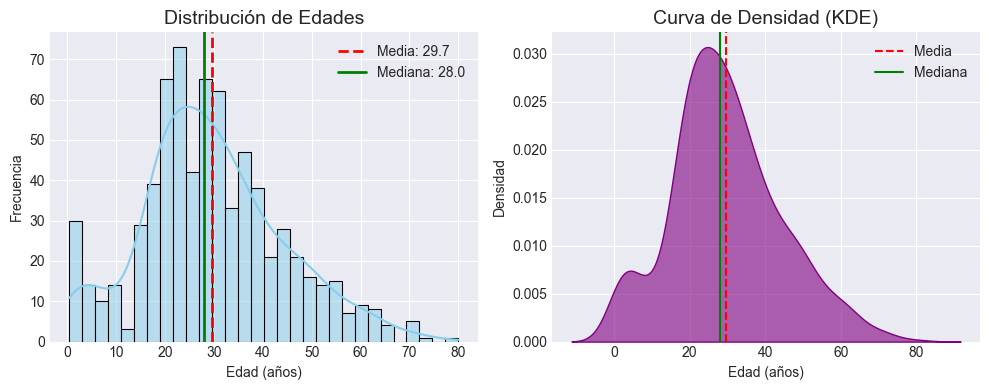

In [28]:
plt.style.use('seaborn-v0_8-darkgrid') 
fig, axes = plt.subplots(1,2, figsize=(10, 4))


ax1 = axes[0]
sns.histplot(train['Age'].dropna(), bins=30, kde=True, ax=ax1, color='skyblue', edgecolor='black')
ax1.axvline(train['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f"Media: {train['Age'].mean():.1f}")
ax1.axvline(train['Age'].median(), color='green', linestyle='-', linewidth=2, label=f"Mediana: {train['Age'].median():.1f}")
ax1.set_title('Distribución de Edades', fontsize=14)
ax1.set_xlabel('Edad (años)')
ax1.set_ylabel('Frecuencia')
ax1.legend()


ax3 = axes[1]
sns.kdeplot(train['Age'].dropna(), ax=ax3, fill=True, color='purple', alpha=0.6)
ax3.axvline(train['Age'].mean(), color='red', linestyle='--', label='Media')
ax3.axvline(train['Age'].median(), color='green', linestyle='-', label='Mediana')
ax3.set_title('Curva de Densidad (KDE)', fontsize=14)
ax3.set_xlabel('Edad (años)')
ax3.set_ylabel('Densidad')
ax3.legend()


plt.tight_layout()
plt.show()

In [29]:
#Procedemos a usar la mediana para completar los valores NA en train[Age]

In [30]:
# Para Age (numérica) - puede ser mean o median
train['Age'] = train['Age'].fillna(train['Age'].median())  # o .mean()

# Para Embarked (categórica) - debe ser mode
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

In [39]:
train['Cabin2'] = train['Cabin'].str[0]
train['Cabin2']=train['Cabin2'].fillna('UNKNOWN')
train['Cabin2'] 

0      UNKNOWN
1            C
2      UNKNOWN
3            C
4      UNKNOWN
        ...   
886    UNKNOWN
887          B
888    UNKNOWN
889          C
890    UNKNOWN
Name: Cabin2, Length: 891, dtype: object

In [41]:
train['Cabin2'].unique()

array(['UNKNOWN', 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [43]:
train['Cabin'] = train['Cabin2']

In [44]:
train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
Cabin2         0
dtype: int64

In [47]:
train = train.drop('Cabin2',axis=1)
print(train.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [53]:
train.groupby('Cabin')['Survived'].mean()

Cabin
A          0.466667
B          0.744681
C          0.593220
D          0.757576
E          0.750000
F          0.615385
G          0.500000
T          0.000000
UNKNOWN    0.299854
Name: Survived, dtype: float64

In [ ]:
#Promedio de edad de sobrevivientes

In [62]:
train.groupby('Survived')['Age'].mean()

Survived
0    30.028233
1    28.291433
Name: Age, dtype: float64

In [ ]:
#Convertimos variables categóricas a numéricas

In [75]:
columnas_a_usar= ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked','Cabin']
char_a_num = pd.get_dummies(train[columnas_a_usar],columns=['Sex','Embarked','Cabin'],drop_first=True)

X=char_a_num
y=train['Survived']

print(f"columnas_a_usar_finales: {X.columns.tolist()}")
print(f"Dimensiones: {X.shape}")

columnas_a_usar_finales: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Cabin_B', 'Cabin_C', 'Cabin_D', 'Cabin_E', 'Cabin_F', 'Cabin_G', 'Cabin_T', 'Cabin_UNKNOWN']
Dimensiones: (891, 16)


In [81]:
import sklearn as skl
from sklearn.model_selection import train_test_split
X_train,X_val,y_train,y_val= train_test_split(X,y,test_size=0.2,random_state=42)
print(f"Entrenamiento:{X_train.shape}, Validacion:{X_val.shape}")

Entrenamiento:(712, 16), Validacion:(179, 16)


In [89]:
from sklearn.ensemble import RandomForestClassifier
modelo= RandomForestClassifier(n_estimators=200, random_state=42)
modelo.fit(X_train,y_train)
print("OK") 

OK


In [90]:
predicciones = modelo.predict(X_val)

In [91]:
predicciones

array([0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1])

In [92]:
from sklearn.metrics import accuracy_score
precision = accuracy_score(y_val, predicciones)
print(f"Precision:{precision:.2f}")

Precision:0.79
